<a href="https://colab.research.google.com/github/MedAhouir/DL_TP/blob/main/DL_TP2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1) Télécharger le code et le dataset ; installer keras et tensorflow et tester le code

In [1]:
!pip install tensorflow keras matplotlib

# 2) Analysez le code et insérez des commentaires expliquant le rôle des sections principales

Importation du bibliothèques:

In [5]:
import os
from keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Activation, Flatten, Dense
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Section paramètres**

Cette section définit les paramètres du modèle et des données :

  * img_width, img_height : dimensions des images (224×224)
  * epochs : nombre d’itérations d’apprentissage
  * batch_size : nombre d’images traitées en même temps
  * num_filters : nombre de filtres dans la couche convolutionnelle
  * input_shape : format de l’image d’entrée.

In [7]:
## Définition du dossier de travail
os.chdir("/content/drive/MyDrive/DL/TP/v_data")
## Taille des images en entrée
img_width, img_height = 224, 224
## Répertoires des données d'entraînement et de test
train_data_dir = 'DL/TP/v_data/train'
validation_data_dir = 'DL/TP/v_data/test'
## Nombre d’échantillons
nb_train_samples = 400
b_validation_samples = 100
#epoque , iteration ,Paramètres d’apprentissage
epochs = 15
batch_size = 16
# Paramètres de convolution
num_filters = 8
filter_size = 3
#on fixe la forme des images en entrée selon l’ordre des dimensions utilisé par Keras.
if K.image_data_format() == 'channels_first':
  #input shape:la taille des données d’entrée données au réseau
 input_shape = (3, img_width, img_height)
else:
 input_shape = (img_width, img_height, 3)
 #(canaux, hauteur, largeur)


**Section transformation des données**

Cette section effectue la prétraitement des images.
Les transformations appliquées sont :

  * normalisation des pixels (division par 255)
  * zoom
  * rotation/shear
  * flip horizontal

Ces transformations permettent d’augmenter artificiellement la quantité de données (data augmentation) et d'améliorer la capacité de généralisation du modèle.

In [10]:
## Générateur de données avec augmentation pour l'entraînement
train_datagen = ImageDataGenerator(rescale = 1. / 255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)
## Générateur de données pour le test, avec seulement normalisation
test_datagen = ImageDataGenerator(rescale = 1. / 255)

# Fix for the incorrect paths due to os.chdir in a previous cell
# Assuming 'train' and 'test' directories are directly under the CWD set by os.chdir
local_train_data_dir = 'train'
local_validation_data_dir = 'test'

## Chargement des images d'entraînement
train_generator = train_datagen.flow_from_directory(local_train_data_dir,
                  target_size =(img_width, img_height),
                  batch_size = batch_size, class_mode ='categorical')
# Chargement des images de validation
validation_generator = test_datagen.flow_from_directory(
                       local_validation_data_dir,
                       target_size =(img_width, img_height),
                       batch_size = batch_size,
                       class_mode ='categorical')

Found 400 images belonging to 2 classes.
Found 100 images belonging to 2 classes.


**Section architecture du CNN**

Le modèle est construit avec le modèle séquentiel de Keras.

Architecture utilisée :
  * **Couche convolutionnelle:** Elle applique des filtres pour extraire les caractéristiques de l’image.
  * **Fonction d’activation ReLU**: Introduit de la non-linéarité dans le réseau.
  * **Couche MaxPooling:** Réduit la dimension des images tout en conservant les caractéristiques importantes.
  * **Flatten:** Transforme la matrice des caractéristiques en vecteur.
  * **Couche dense:** Couche entièrement connectée pour combiner les caractéristiques.
  * **Couche de sortie:** Produit la classification finale entre les deux classes.

In [11]:
## Construction du modèle CNN
model = Sequential()
model.add(Conv2D(num_filters, (3,3), input_shape = input_shape))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size = (2, 2)))
model.add(Flatten())
model.add(Dense(24))
model.add(Dense(2))
model.add(Activation('sigmoid'))
print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 222, 222, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 98568)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │     2,365,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,365,930 (9.03 MB)

 Trainable params: 2,365,930 (9.03 MB)

 Non-trainable params: 0 (0.00 B)

None


**Section entraînement:**

**Loss:** fonction de coût ;

**Optimizer:** méthode d’optimisation ;

**Accuracy:** mesure de performance.

In [12]:
model.compile(loss ='binary_crossentropy',
  optimizer ='rmsprop',metrics =['accuracy'])

#entraîne le modèle sur les images d’apprentissage et l’évalue sur les images de validation
history=model.fit(train_generator,
  steps_per_epoch = nb_train_samples // batch_size,
  epochs = epochs, validation_data = validation_generator,
  validation_steps = b_validation_samples // batch_size)

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 357s 14s/step - accuracy: 0.4575 - loss: 18.4730 - val_accuracy: 0.5104 - val_loss: 4.0072
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 263ms/step - accuracy: 0.7125 - loss: 2.0334 - val_accuracy: 0.8542 - val_loss: 0.4990
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 227ms/step - accuracy: 0.7675 - loss: 0.8873 - val_accuracy: 0.8750 - val_loss: 0.3302
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 310ms/step - accuracy: 0.8200 - loss: 0.5137 - val_accuracy: 0.8333 - val_loss: 0.3943
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 228ms/step - accuracy: 0.8200 - loss: 0.4449 - val_accuracy: 0.8438 - val_loss: 0.4201
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 300ms/step - accuracy: 0.8200 - loss: 0.4579 - val_accuracy: 0.8438 - val_loss: 0.4882
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 227ms/step - accuracy: 0.8575 - loss: 0.3795 - val_accuracy: 0.8229 - val_loss: 0.4013
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 307ms/step - accuracy: 0.8725 - loss: 0.3555 - val_accuracy: 0

**Section visualisation**

Cette partie trace deux graphiques :

**1 - Accuracy**

**2 - Loss**

Ces graphiques permettent d’observer l’évolution des performances du modèle pendant l’apprentissage.

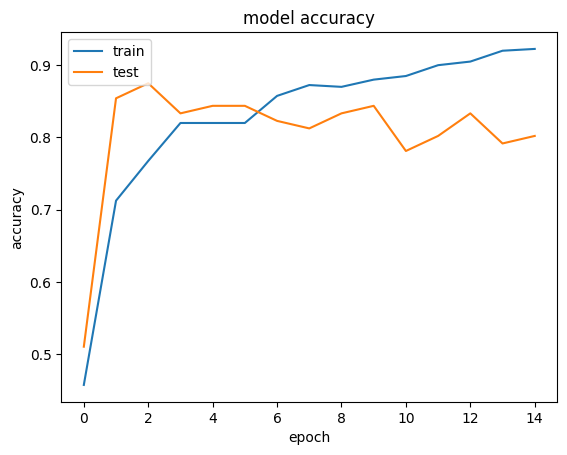

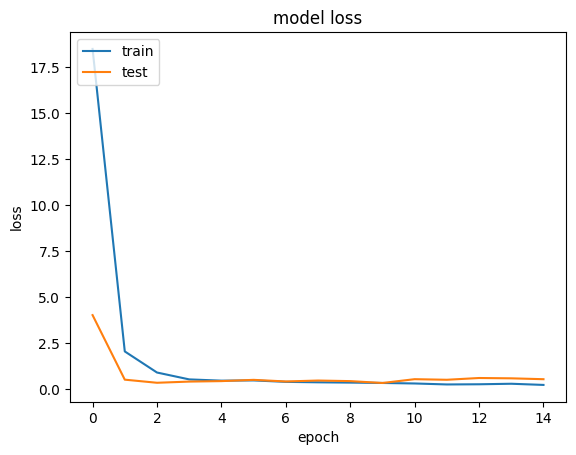

In [13]:
#Affichage des courbes d’accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# 3) Changez la section de code :

Found 400 images belonging to 2 classes.
Found 100 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 222, 222, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 98568)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │     2,365,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,365,930 (9.03 MB)

 Trainable params: 2,365,930 (9.03 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 112s 4s/step - accuracy: 0.4675 - loss: 24.6029 - val_accuracy: 0.5417 - val_loss: 11.9762
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 284ms/step - accuracy: 0.6150 - loss: 8.1666 - val_accuracy: 0.8229 - val_loss: 5.7804
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 206ms/step - accuracy: 0.7625 - loss: 2.2069 - val_accuracy: 0.8750 - val_loss: 0.3977
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 208ms/step - accuracy: 0.8000 - loss: 0.8759 - val_accuracy: 0.8438 - val_loss: 0.3862
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 215ms/step - accuracy: 0.8250 - loss: 0.4856 - val_accuracy: 0.8958 - val_loss: 0.3462
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 270ms/step - accuracy: 0.8375 - loss: 0.5210 - val_accuracy: 0.8854 - val_loss: 0.3132
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 209ms/step - accuracy: 0.8475 - loss: 0.4152 - val_accuracy: 0.8750 - val_loss: 0.3513
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 280ms/step - accuracy: 0.8800 - loss: 0.3097 - val_accur

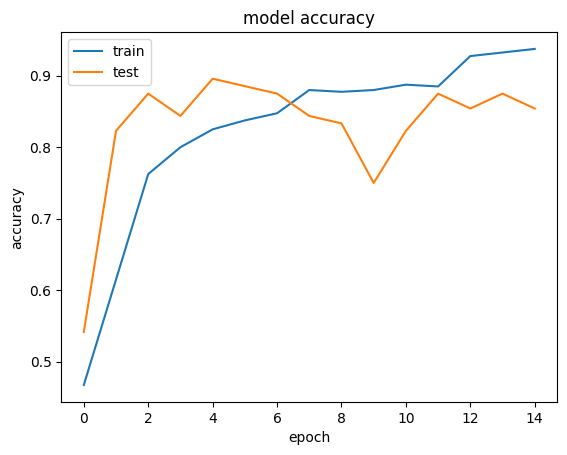

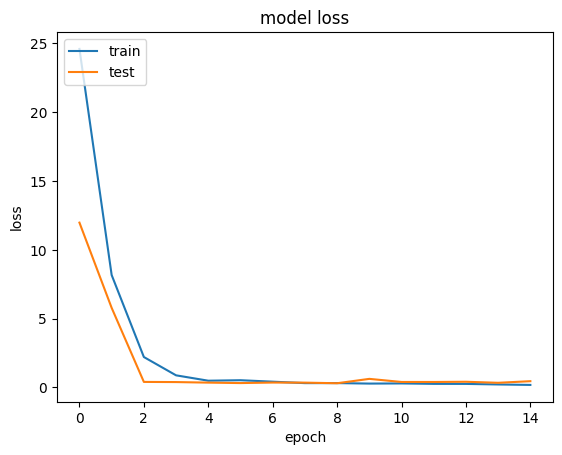

In [11]:
import os
from keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Activation, Flatten, Dense
import matplotlib.pyplot as plt

# Définition du dossier de travail
os.chdir("/content/drive/MyDrive/DL/TP/v_data")

# Taille des images en entrée
img_width, img_height = 224, 224

# Répertoires des données d'entraînement et de test
train_data_dir = 'train'
validation_data_dir = 'test'

# Nombre d’échantillons
nb_train_samples = 400
nb_validation_samples = 100

# Paramètres d’apprentissage
epochs = 15
batch_size = 16

# Paramètres de convolution
num_filters = 8
filter_size = 3

# Définition de la forme des images en entrée
if K.image_data_format() == 'channels_first':
    input_shape = (3, img_width, img_height)
else:
    input_shape = (img_width, img_height, 3)

# Générateur de données avec augmentation pour l'entraînement
train_datagen = ImageDataGenerator(rescale = 1. / 255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

# Générateur de données pour le test, avec seulement normalisation
test_datagen = ImageDataGenerator(rescale=1. / 255)

# Chargement des images d'entraînement
train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical'
)

# Chargement des images de validation
validation_generator = test_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical'
)

# Construction du modèle CNN
model = Sequential()
model.add(Conv2D(num_filters, (3, 3), input_shape=input_shape))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(24))
model.add(Dense(2))
model.add(Activation('sigmoid'))

# Résumé de l’architecture
print(model.summary())

# Compilation du modèle
model.compile(loss='binary_crossentropy',
              optimizer='rmsprop',
              metrics=['accuracy'])

# Entraînement du modèle
history = model.fit(
    train_generator,
    steps_per_epoch=nb_train_samples // batch_size,
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=nb_validation_samples // batch_size
)

# Affichage des courbes d’accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# Affichage des courbes de loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

Quel est l’effet sur les performances en classfication ?

Le modèle s’entraîne uniquement sur les images originales, ce qui réduit la diversité des données et peut entraîner un overfitting, donc des performances de classification plus faibles sur les données de test.

# 4) Nouvelle architecture CNN proposée

In [12]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Activation, Flatten, Dense, Dropout

model = Sequential()

model.add(Conv2D(16, (3,3), input_shape=input_shape, padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(32, (3,3), padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, (3,3), padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(64))
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(2))
model.add(Activation('softmax'))

model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 224, 224, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     3,211,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,235,042 (12.34 MB)

 Trainable params: 3,235,042 (12.34 MB)

 Non-trainable params: 0 (0.00 B)

None


Pourquoi cette architecture peut être meilleure?

Avantages

* plus de couches convolutionnelles → meilleure extraction de caractéristiques
* dropout → réduit l’overfitting
* amélioration possible de l’accuracy.

Les performances doivent être évaluées en comparant les courbes accuracy et loss avec celles du modèle initial.

# 5) Classification avec la luminance (images en niveaux de gris)

Pour utiliser uniquement la luminance, il faut convertir les images en grayscale.

Les modifications nécessaires sont :

**Modifier la forme de l’entrée**



In [ ]:
input_shape = (img_width, img_height, 1)

Le 1 représente un seul canal (gris) au lieu de 3 canaux RGB.

**Modifier le générateur d’images**

In [ ]:
train_generator = train_datagen.flow_from_directory(
train_data_dir,
target_size=(img_width,img_height),
batch_size=batch_size,
class_mode='categorical',
color_mode='grayscale')


Même modification pour validation_generator.

**Effet**

* les images sont traitées uniquement selon leur intensité lumineuse
* le modèle devient plus simple et plus rapide
* mais certaines informations de couleur peuvent être perdues.